![gym](../gym.png)


You are a product manager for a fitness studio and are interested in understanding the current demand for digital fitness classes. You plan to conduct a market analysis in Python to gauge demand and identify potential areas for growth of digital products and services.

### The Data

You are provided with a number of CSV files in the "Files/data" folder, which offer international and national-level data on Google Trends keyword searches related to fitness and related products. 

### workout.csv

| Column     | Description              |
|------------|--------------------------|
| `'month'` | Month when the data was measured. |
| `'workout_worldwide'` | Index representing the popularity of the keyword 'workout', on a scale of 0 to 100. |

### three_keywords.csv

| Column     | Description              |
|------------|--------------------------|
| `'month'` | Month when the data was measured. |
| `'home_workout_worldwide'` | Index representing the popularity of the keyword 'home workout', on a scale of 0 to 100. |
| `'gym_workout_worldwide'` | Index representing the popularity of the keyword 'gym workout', on a scale of 0 to 100. |
| `'home_gym_worldwide'` | Index representing the popularity of the keyword 'home gym', on a scale of 0 to 100. |

### workout_geo.csv

| Column     | Description              |
|------------|--------------------------|
| `'country'` | Country where the data was measured. |
| `'workout_2018_2023'` | Index representing the popularity of the keyword 'workout' during the 5 year period. |

### three_keywords_geo.csv

| Column     | Description              |
|------------|--------------------------|
| `'country'` | Country where the data was measured. |
| `'home_workout_2018_2023'` | Index representing the popularity of the keyword 'home workout' during the 5 year period. |
| `'gym_workout_2018_2023'` | Index representing the popularity of the keyword 'gym workout' during the 5 year period.  |
| `'home_gym_2018_2023'` | Index representing the popularity of the keyword 'home gym' during the 5 year period. |

In [1]:
# Import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

In [2]:
# Start coding here
workout = pd.read_csv('../data/raw/workout.csv')
print(workout.head())

     month  workout_worldwide
0  2018-03                 59
1  2018-04                 61
2  2018-05                 57
3  2018-06                 56
4  2018-07                 51


In [3]:
row_of_highest_workout= workout[workout['workout_worldwide']== workout['workout_worldwide'].max()]
row_of_highest_workout['month'] = pd.to_datetime(row_of_highest_workout['month'])
print(row_of_highest_workout)

        month  workout_worldwide
25 2020-04-01                100


C:\Users\ayush\AppData\Local\Temp\ipykernel_28840\1099970030.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  row_of_highest_workout['month'] = pd.to_datetime(row_of_highest_workout['month'])


In [4]:
year_str1 = row_of_highest_workout['month'].dt.year
print(year_str1)
year_str = '2020'

25    2020
Name: month, dtype: int32


<Axes: xlabel='month'>

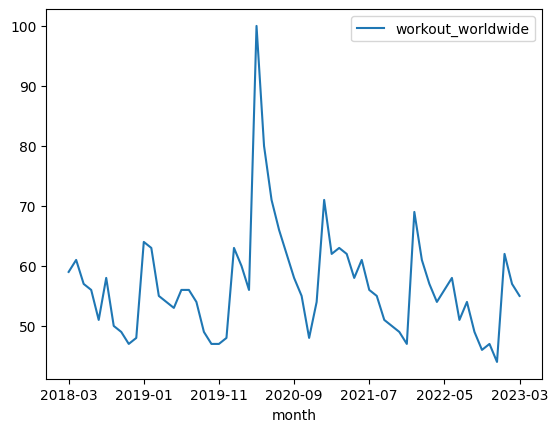

In [5]:
# required_data = workout[pd.to_datetime(workout['month'])]
workout.plot(kind='line', x = 'month',y='workout_worldwide')


In [6]:
three_keywords = pd.read_csv('../data/raw/three_keywords.csv')
print(three_keywords.head())

     month  home_workout_worldwide  gym_workout_worldwide  home_gym_worldwide
0  2018-03                      12                     16                  10
1  2018-04                      12                     18                  10
2  2018-05                      13                     16                   9
3  2018-06                      12                     17                   9
4  2018-07                      12                     17                   9


In [7]:
three_keywords['month'] = pd.to_datetime(three_keywords['month'])
three_keywords.head()


,month,home_workout_worldwide,gym_workout_worldwide,home_gym_worldwide
0,2018-03-01,12,16,10
1,2018-04-01,12,18,10
2,2018-05-01,13,16,9
3,2018-06-01,12,17,9
4,2018-07-01,12,17,9


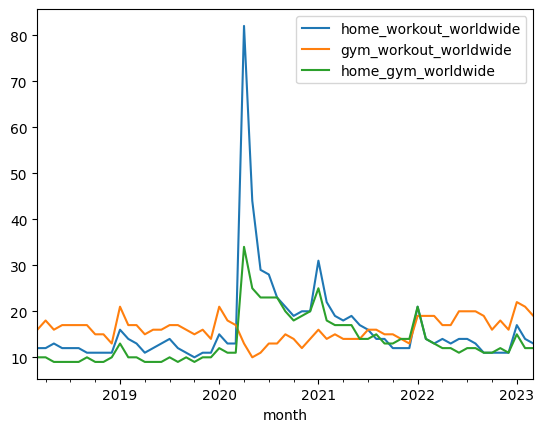

In [8]:
three_keywords.plot(kind= 'line', x='month', y=['home_workout_worldwide','gym_workout_worldwide','home_gym_worldwide'])
plt.show()

In [9]:
peak_covid = 'home_workout_worldwide'
print(peak_covid)
current = 'gym_workout_worldwide'
print(current)

home_workout_worldwide
gym_workout_worldwide


In [10]:
workout_geo = pd.read_csv('../data/raw/workout_geo.csv')
print(workout_geo.head())


                             country  workout_2018_2023
0                               Guam                NaN
1  Falkland Islands (Islas Malvinas)                NaN
2                       Cook Islands                NaN
3                             Brunei                NaN
4                              Palau                NaN


In [11]:
required_countries = workout_geo[workout_geo['country'].isin(['United States','Australia','Japan'])]
print(required_countries)

           country  workout_2018_2023
5    United States              100.0
18       Australia               77.0
216          Japan                1.0


In [12]:
top_country = 'United States'
print(top_country)

United States


In [13]:
last_data = pd.read_csv('../data/raw/three_keywords_geo.csv')
print(last_data.head())

     Country  home_workout_2018_2023  gym_workout_2018_2023  \
0  Gibraltar                     NaN                    NaN   
1    Lesotho                     NaN                    NaN   
2       Guam                     NaN                    NaN   
3   Botswana                     NaN                    NaN   
4     Brunei                     NaN                    NaN   

   home_gym_2018_2023  
0                 NaN  
1                 NaN  
2                 NaN  
3                 NaN  
4                 NaN  


In [14]:
# mesa_countries = last_data[last_data['Country'].isin(['Philippines','Malaysia'])]
# print(mesa_countries.sort_values("home_workout_2018_2023",ascending = False))
# print(last_data.loc[['Philippines','Malaysia'],'home_workout_2018_2023'])

mesa_countries = last_data[last_data['Country'].isin(['Philippines','Malaysia'])]
mesa_countries.set_index('Country')

print(mesa_countries[['Country','home_workout_2018_2023']].sort_values('home_workout_2018_2023',ascending=False))

        Country  home_workout_2018_2023
23  Philippines                    52.0
61     Malaysia                    47.0


In [15]:
home_workout_geo = "Philippines"
print(home_workout_geo)

Philippines


<Axes: xlabel='Country'>

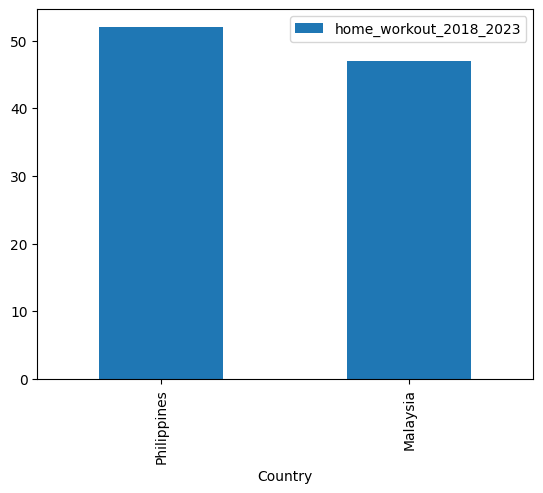

In [16]:
mesa_countries.plot(x='Country',y='home_workout_2018_2023',kind='bar')
